# Poisson Sandbox — del precio de Polymarket al modelo de goles

Este cuaderno demuestra el **motor de probabilidades de fútbol** ya implementado en `src/`.
La idea central del negocio es simple:

> Polymarket cotiza el resultado de un partido como precios 1X2 (local / empate / visita).
> Esos precios son, en esencia, **probabilidades implícitas**. Si podemos traducirlos a un
> modelo de goles (Poisson o Dixon-Coles), podemos:
> 1. Calcular **cualquier mercado derivado** (marcador exacto, Over/Under, etc.) de forma coherente.
> 2. **Actualizar el precio justo en vivo** a medida que avanza el partido y llega el xG real.

El partido de ejemplo es **Argentina vs Cabo Verde**: un favorito muy fuerte de local.

El flujo del cuaderno:
1. Precios iniciales y normalización.
2. Calibración Poisson vs Dixon-Coles lado a lado.
3. Tabla de marcadores más probables + Over 2.5.
4. Escenario live al minuto 30 con 0-0 y xG bajo vs alto del favorito.
5. Curva del precio justo del empate si el partido sigue 0-0.

## 1. Setup

El cuaderno corre desde `notebooks/`, así que lo primero es agregar la raíz del
proyecto al `sys.path` para poder importar `src`.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

from src.utils.config import load_config
from src.models import calibration, poisson, dixon_coles, live_update
import matplotlib.pyplot as plt

cfg = load_config()
MAX_GOALS = cfg["max_goals"]
print("Config cargada. max_goals =", MAX_GOALS)

Matplotlib is building the font cache; this may take a moment.


Config cargada. max_goals = 12


## 2. Precios iniciales y normalización

Supongamos que Polymarket cotiza Argentina vs Cabo Verde así:

| Resultado | Precio |
|-----------|-------|
| Local (Argentina) | 0.86 |
| Empate | 0.11 |
| Visita (Cabo Verde) | 0.04 |

Los precios crudos no suman exactamente 1 (incluyen un pequeño *overround*).
`normalize_prices` los reescala para que sumen 1 y queden como probabilidades limpias.

In [2]:
p_home, p_draw, p_away = 0.86, 0.11, 0.04

market = calibration.normalize_prices(p_home, p_draw, p_away)

print("Precios crudos:   home=%.2f  draw=%.2f  away=%.2f  (suma=%.3f)"
      % (p_home, p_draw, p_away, p_home + p_draw + p_away))
print("Probabilidades:   home=%.4f  draw=%.4f  away=%.4f  (suma=%.4f)"
      % (market["home"], market["draw"], market["away"],
         market["home"] + market["draw"] + market["away"]))

Precios crudos:   home=0.86  draw=0.11  away=0.04  (suma=1.010)
Probabilidades:   home=0.8515  draw=0.1089  away=0.0396  (suma=1.0000)


## 3. Calibración: Poisson vs Dixon-Coles lado a lado

`calibrate` busca los parámetros (lambdas, y opcionalmente rho) que mejor reproducen
las probabilidades del mercado. Comparamos los dos modelos:

- **Poisson**: goles del local y visita son Poisson independientes. Calibra 2 lambdas.
- **Dixon-Coles**: igual, pero con un parámetro `rho` que **redistribuye la masa de los
  marcadores bajos** (0-0, 1-0, 0-1, 1-1) para capturar la correlación que el Poisson puro
  ignora. Aquí `rho` queda fijo en el valor de config (`default_rho`).

Lo interesante: **ambos reproducen casi exactamente el mismo 1X2 de mercado**, pero con
**lambdas distintas**, justamente porque Dixon-Coles compensa la corrección de marcadores
bajos subiendo las lambdas.

In [3]:
def fit_and_probs(model):
    res = calibration.calibrate(market, model=model, config=cfg)
    if model == "dixon_coles":
        m = dixon_coles.score_matrix(res["lambda_home"], res["lambda_away"],
                                     res["rho"], MAX_GOALS)
    else:
        m = poisson.score_matrix(res["lambda_home"], res["lambda_away"], MAX_GOALS)
    return res, poisson.outcome_probs(m)

res_pois, probs_pois = fit_and_probs("poisson")
res_dc,   probs_dc   = fit_and_probs("dixon_coles")

print("Mercado objetivo:   home=%.4f  draw=%.4f  away=%.4f" %
      (market["home"], market["draw"], market["away"]))
print()
header = "%-14s %9s %9s %7s %12s %9s %9s %9s %8s" % (
    "Modelo", "lam_home", "lam_away", "rho", "loss", "1X2 home", "1X2 draw", "1X2 away", "warns")
print(header)
print("-" * len(header))
for name, res, probs in [("Poisson", res_pois, probs_pois),
                         ("Dixon-Coles", res_dc, probs_dc)]:
    print("%-14s %9.4f %9.4f %7.3f %12.2e %9.4f %9.4f %9.4f %8d" % (
        name, res["lambda_home"], res["lambda_away"], res["rho"], res["loss"],
        probs["home"], probs["draw"], probs["away"], len(res["warnings"])))

Mercado objetivo:   home=0.8515  draw=0.1089  away=0.0396

Modelo          lam_home  lam_away     rho         loss  1X2 home  1X2 draw  1X2 away    warns
----------------------------------------------------------------------------------------------
Poisson           2.7587    0.4551  -0.130     1.65e-10    0.8515    0.1089    0.0396        0
Dixon-Coles       3.1511    0.6423  -0.130     1.45e-11    0.8515    0.1089    0.0396        0


**Lectura.** Las dos filas de "1X2" se pegan al mercado (`loss` ~ 0), pero fíjate en las
lambdas: Dixon-Coles necesita lambdas **más altas** que Poisson para llegar al mismo 1X2,
porque su corrección rho < 0 le quita masa a los marcadores muy bajos y hay que "reponerla"
con más goles esperados.

## 4. Tabla de marcadores más probables (ajuste Poisson)

Con la matriz de marcadores del ajuste Poisson, `top_scores` nos da los resultados más
probables. Como Argentina es favorito fuerte de local, dominan los marcadores con varios
goles locales y cero de la visita.

También calculamos **Over 2.5** = `P(goles totales >= 3)`.

In [4]:
matrix_pois = poisson.score_matrix(res_pois["lambda_home"],
                                   res_pois["lambda_away"], MAX_GOALS)

top = poisson.top_scores(matrix_pois, n=10)

print("%-4s %-12s %10s" % ("#", "Marcador", "Prob"))
print("-" * 28)
for rank, (home_goals, away_goals, prob) in enumerate(top, start=1):
    print("%-4d %-12s %9.2f%%" % (rank, "%d - %d" % (home_goals, away_goals), prob * 100))

over_2_5 = poisson.prob_total_goals_at_least(matrix_pois, 3)
print()
print("Over 2.5 (P(goles totales >= 3)) = %.2f%%" % (over_2_5 * 100))

#    Marcador           Prob
----------------------------
1    2 - 0            15.30%
2    3 - 0            14.07%
3    1 - 0            11.09%
4    4 - 0             9.70%
5    2 - 1             6.96%
6    3 - 1             6.40%
7    5 - 0             5.35%
8    1 - 1             5.05%
9    4 - 1             4.42%
10   0 - 0             4.02%

Over 2.5 (P(goles totales >= 3)) = 62.30%


## 5. Escenario live: minuto 30, 0-0, xG bajo vs alto del favorito

Aquí está el corazón del valor del motor. Estamos al **minuto 30, sigue 0-0**. Pero un 0-0
no dice nada por sí solo: importa *cómo* se llegó a ese 0-0.

Construimos dos estados con el **mismo marcador** pero distinto xG del favorito:

- **xG bajo** (`home_xg=0.2`): Argentina no genera nada, el partido está trabado.
- **xG alto** (`home_xg=1.3`): Argentina remata sin parar y le falta solo el gol.

`adjusted_remaining_lambdas` ajusta las lambdas *restantes* mezclando el prior del mercado
con el ritmo real implícito por el xG. `live_outcome_probs` condiciona al marcador actual.

In [5]:
lh, la = res_pois["lambda_home"], res_pois["lambda_away"]

estados = {
    "xG bajo (home_xg=0.2)": live_update.MatchState(
        minute=30, home_score=0, away_score=0, home_xg=0.2, away_xg=0.1),
    "xG alto (home_xg=1.3)": live_update.MatchState(
        minute=30, home_score=0, away_score=0, home_xg=1.3, away_xg=0.1),
}

header = "%-26s %12s %12s %9s %9s %9s" % (
    "Escenario (min 30, 0-0)", "lam_rem_home", "lam_rem_away",
    "P_home", "P_draw", "P_away")
print(header)
print("-" * len(header))
for nombre, state in estados.items():
    rem = live_update.adjusted_remaining_lambdas(lh, la, state, cfg)
    live = live_update.live_outcome_probs(lh, la, state, cfg, model="poisson")
    print("%-26s %12.4f %12.4f %9.4f %9.4f %9.4f" % (
        nombre, rem["lambda_home"], rem["lambda_away"],
        live["home"], live["draw"], live["away"]))

Escenario (min 30, 0-0)    lam_rem_home lam_rem_away    P_home    P_draw    P_away
----------------------------------------------------------------------------------
xG bajo (home_xg=0.2)            1.0541       0.2470    0.5660    0.3478    0.0862
xG alto (home_xg=1.3)            2.2541       0.2470    0.8359    0.1344    0.0297


**El "0-0 engañoso".** Mismo marcador, misma cantidad de minutos jugados, pero:

- Con **xG bajo**, P_draw sube fuerte (el empate es un escenario muy vivo: nadie genera).
- Con **xG alto**, P_draw **se desploma** y P_home se dispara: el favorito está dominando y
  el gol "se huele". El mercado que solo mira el marcador (0-0) está subvaluando a Argentina.

Ahí está el edge: dos partidos idénticos en el tablero, precios justos muy distintos.

## 6. Curva del precio justo del empate si el partido sigue 0-0

Si el 0-0 se mantiene, ¿cómo evoluciona la probabilidad del empate minuto a minuto?
`fair_draw_curve` lo calcula de 0 a 90. Intuición: a medida que queda menos tiempo para que
Argentina rompa el 0-0, el empate se vuelve cada vez más probable, hasta llegar a P_draw = 1
en el minuto 90 (si sigue 0-0, *es* empate).

In [6]:
curve = live_update.fair_draw_curve(lh, la, cfg, model="poisson",
                                    minutes=range(0, 91, 5))

print("%6s %9s %9s %9s %12s" % ("min", "P_home", "P_draw", "P_away", "P(0-0 final)"))
print("-" * 50)
for row in curve:
    print("%6d %9.4f %9.4f %9.4f %12.4f" % (
        row["minute"], row["p_home"], row["p_draw"], row["p_away"], row["p_0_0_final"]))

   min    P_home    P_draw    P_away P(0-0 final)
--------------------------------------------------
     0    0.8515    0.1089    0.0396       0.0402
     5    0.8392    0.1190    0.0419       0.0481
    10    0.8256    0.1302    0.0442       0.0575
    15    0.8105    0.1430    0.0466       0.0687
    20    0.7937    0.1574    0.0490       0.0821
    25    0.7749    0.1738    0.0513       0.0982
    30    0.7538    0.1926    0.0537       0.1174
    35    0.7300    0.2142    0.0558       0.1403
    40    0.7029    0.2393    0.0578       0.1677
    45    0.6721    0.2686    0.0594       0.2005
    50    0.6366    0.3029    0.0604       0.2397
    55    0.5956    0.3436    0.0607       0.2866
    60    0.5479    0.3921    0.0600       0.3426
    65    0.4920    0.4502    0.0578       0.4095
    70    0.4259    0.5204    0.0537       0.4896
    75    0.3472    0.6059    0.0469       0.5853
    80    0.2528    0.7106    0.0366       0.6997
    85    0.1388    0.8397    0.0215       0.8365

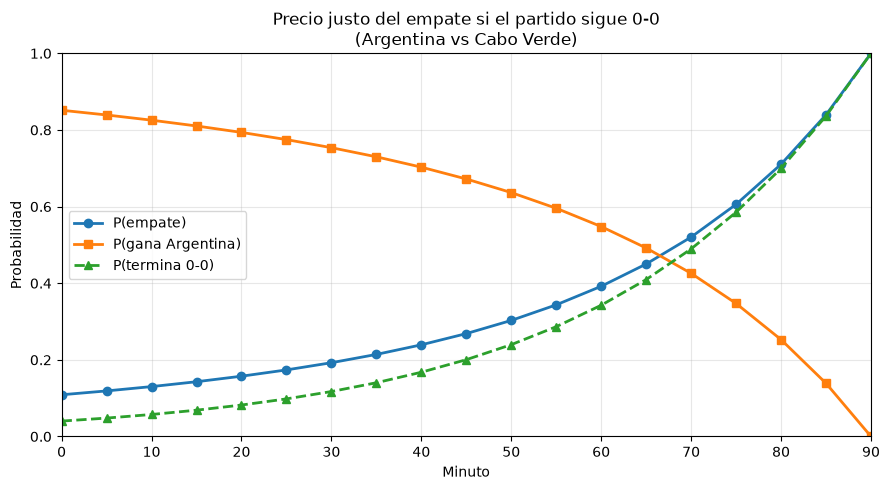

In [7]:
minutes   = [row["minute"]      for row in curve]
p_draw    = [row["p_draw"]      for row in curve]
p_home    = [row["p_home"]      for row in curve]
p_0_0     = [row["p_0_0_final"] for row in curve]

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(minutes, p_draw, marker="o", linewidth=2, label="P(empate)")
ax.plot(minutes, p_home, marker="s", linewidth=2, label="P(gana Argentina)")
ax.plot(minutes, p_0_0,  marker="^", linewidth=2, linestyle="--",
        label="P(termina 0-0)")

ax.set_title("Precio justo del empate si el partido sigue 0-0\n(Argentina vs Cabo Verde)")
ax.set_xlabel("Minuto")
ax.set_ylabel("Probabilidad")
ax.set_xlim(0, 90)
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

**Interpretación.** La curva del empate sube de forma monótona y se acelera en el tramo
final: empieza cerca de ~0.11 (el precio inicial del empate) y llega a 1.0 en el minuto 90.
En espejo, P(gana Argentina) cae a 0. Esta es exactamente la dinámica que un trader quiere
tener cuantificada: si el empate sigue cotizando barato al minuto 70 y el partido sigue 0-0,
el modelo dice que el precio justo ya es mucho más alto. Ahí aparece la oportunidad.